# Training a Deeper Neural Network — Backpropagation

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture that scales **backpropagation** to
a multi-layer network (Week 3 — Optimization in Neural Networks and Newton's Method).

This notebook explains:

- a **three-layer** network and the **superscript** notation $w^{(\ell)}, z^{(\ell)}, a^{(\ell)}$
- backpropagation as a long **chain rule**, layer by layer
- the key efficiency idea: **store and reuse** already-computed derivatives
- a general, vectorized **MLP** with forward + backward passes
- a numeric gradient check and training on a nonlinear dataset

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*Classification with a Neural Network — Minimizing the Log Loss*.

## 1. A bigger network and its notation

We now stack more layers: inputs $x_1, x_2$ → a **first** hidden layer → a **second** hidden
layer → an **output** producing $\hat{y}$.

To keep track of everything, we use a **superscript** for the layer:

- layer 1: weights/biases $w^{(1)}, b^{(1)}$, summations $z^{(1)}$, activations
  $a^{(1)} = \sigma(z^{(1)})$,
- layer 2: $w^{(2)}, b^{(2)}, z^{(2)}, a^{(2)} = \sigma(z^{(2)})$,
- layer 3 (output): $w^{(3)}, b^{(3)}, z^{(3)}, \hat{y} = \sigma(z^{(3)})$.

Add more layers and the superscripts continue $4, 5, 6, \dots$. The loss is the log loss

$$
L(y, \hat{y}) = -y\log\hat{y} - (1-y)\log(1-\hat{y}).
$$

## 2. Backpropagation = chain rule, layer by layer

**Backpropagation** trains the network by computing $\partial L/\partial(\text{each weight
and bias})$ with the chain rule, then taking a gradient-descent step.

- For an **output** weight $w^{(3)}$, the chain is short — just the variables between
  $w^{(3)}$ and $L$:
  $$
  \frac{\partial L}{\partial w^{(3)}}
  = \frac{\partial z^{(3)}}{\partial w^{(3)}}\,
    \frac{\partial \hat{y}}{\partial z^{(3)}}\,
    \frac{\partial L}{\partial \hat{y}}.
  $$
- For a **deeper** weight $w^{(2)}$, the chain is longer (it must pass through layer 3 to
  reach $L$):
  $$
  \frac{\partial L}{\partial w^{(2)}}
  = \frac{\partial z^{(2)}}{\partial w^{(2)}}\,
    \frac{\partial a^{(2)}}{\partial z^{(2)}}\,
    \frac{\partial z^{(3)}}{\partial a^{(2)}}\,
    \frac{\partial \hat{y}}{\partial z^{(3)}}\,
    \frac{\partial L}{\partial \hat{y}}.
  $$

Every individual factor is either a **linear** function (derivative = a weight or an input)
or a **sigmoid** (derivative = $a(1-a)$), so each is easy.

## 3. The key idea: store and reuse

Notice the tail of the $w^{(2)}$ chain — $\dfrac{\partial \hat{y}}{\partial z^{(3)}}
\dfrac{\partial L}{\partial \hat{y}}$ — is **the same** piece already computed for
$w^{(3)}$.

> *"These have already been calculated, so we don't need to calculate them anymore. There's
> a lot of reuse of variables — store them and continue calculating new ones."*

Backpropagation works **backward** from the output, carrying a running quantity (the
"error" $\delta$) so each layer reuses the next layer's result. That reuse is what makes it
efficient — recomputing each chain from scratch would be wasteful.

> *"The good news: as a practitioner you don't need to do this by hand — great packages do
> it. But it's worth seeing carefully once."*

## 4. A general, vectorized MLP

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def forward(X, Ws, bs):
    # returns final output and the list of activations a^(0..L)
    a = X
    activations = [a]
    for W, b in zip(Ws, bs):
        a = sigmoid(a @ W + b)
        activations.append(a)
    return activations[-1], activations

def log_loss(Y, P, eps=1e-12):
    Y = Y.ravel()
    P = np.clip(P.ravel(), eps, 1 - eps)     # ravel both to avoid (N,)x(N,1) broadcasting
    return np.mean(-Y*np.log(P) - (1-Y)*np.log(1-P))

def backprop(X, Y, Ws, bs):
    n = len(Y)
    y_hat, acts = forward(X, Ws, bs)
    # output-layer error for sigmoid + log loss:  δ = (a_L - y)/n
    delta = (acts[-1] - Y.reshape(-1, 1)) / n
    gWs = [None]*len(Ws); gbs = [None]*len(bs)
    for l in reversed(range(len(Ws))):
        gWs[l] = acts[l].T @ delta            # ∂L/∂W^(l) = a^(l-1)ᵀ δ
        gbs[l] = delta.sum(axis=0, keepdims=True)
        if l > 0:                             # propagate δ backward, reusing it
            a_prev = acts[l]
            delta = (delta @ Ws[l].T) * a_prev * (1 - a_prev)
    return gWs, gbs

## 5. Numeric gradient check

We confirm the backprop gradients against finite differences on a small random network.

In [2]:
rng = np.random.default_rng(0)
Xc = rng.normal(size=(5, 2))
Yc = np.array([0, 1, 1, 0, 1], dtype=float)

# a 2 -> 3 -> 3 -> 1 network
sizes = [2, 3, 3, 1]
Ws = [rng.normal(size=(sizes[i], sizes[i+1])) for i in range(len(sizes)-1)]
bs = [np.zeros((1, sizes[i+1])) for i in range(len(sizes)-1)]

gWs, gbs = backprop(Xc, Yc, Ws, bs)

# check one weight matrix with finite differences
h = 1e-6
W = Ws[1]; gW = gWs[1]
max_err = 0.0
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        Wp = [w.copy() for w in Ws]; Wm = [w.copy() for w in Ws]
        Wp[1][i, j] += h; Wm[1][i, j] -= h
        num = (log_loss(Yc, forward(Xc, Wp, bs)[0]) - log_loss(Yc, forward(Xc, Wm, bs)[0])) / (2*h)
        max_err = max(max_err, abs(num - gW[i, j]))
print(f"max |analytic - numeric| over layer-2 weights = {max_err:.2e} (≈0 confirms backprop)")

max |analytic - numeric| over layer-2 weights = 7.93e-11 (≈0 confirms backprop)


## 6. Training on a nonlinear dataset

We make a "circle" dataset — points **inside** a radius are class 1, outside are class 0 —
which is not linearly separable, and train the 2→hidden→hidden→1 network with backprop.

In [3]:
rng = np.random.default_rng(2)
N = 400
X = rng.uniform(-1, 1, size=(N, 2))
Y = (X[:, 0]**2 + X[:, 1]**2 < 0.5).astype(float)   # inside the circle -> 1

sizes = [2, 8, 8, 1]
Ws = [rng.normal(size=(sizes[i], sizes[i+1])) * 1.0 for i in range(len(sizes)-1)]
bs = [np.zeros((1, sizes[i+1])) for i in range(len(sizes)-1)]

alpha = 1.0
losses = []
for epoch in range(4000):
    gWs, gbs = backprop(X, Y, Ws, bs)
    for l in range(len(Ws)):
        Ws[l] -= alpha * gWs[l]
        bs[l] -= alpha * gbs[l]
    losses.append(log_loss(Y, forward(X, Ws, bs)[0]))

pred = (forward(X, Ws, bs)[0].ravel() >= 0.5).astype(float)
acc = (pred == Y).mean()
print(f"final log loss = {losses[-1]:.4f},  training accuracy = {acc*100:.1f}%")

final log loss = 0.0142,  training accuracy = 99.8%


### Loss curve and the learned boundary

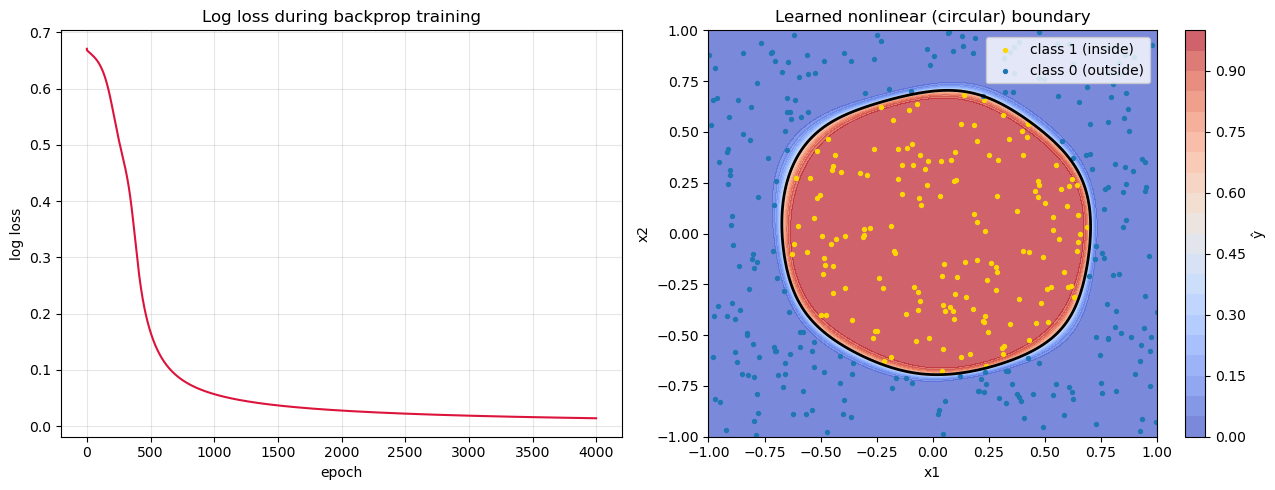

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(losses, color="crimson")
axes[0].set_title("Log loss during backprop training")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("log loss")
axes[0].grid(True, alpha=0.3)

gx = np.linspace(-1, 1, 200); gy = np.linspace(-1, 1, 200)
GX, GY = np.meshgrid(gx, gy)
grid = np.column_stack([GX.ravel(), GY.ravel()])
GZ = forward(grid, Ws, bs)[0].reshape(GX.shape)
cf = axes[1].contourf(GX, GY, GZ, levels=20, cmap="coolwarm", alpha=0.7)
plt.colorbar(cf, ax=axes[1], label="ŷ")
axes[1].contour(GX, GY, GZ, levels=[0.5], colors="black", linewidths=2)
axes[1].scatter(X[Y==1,0], X[Y==1,1], s=8, color="gold", label="class 1 (inside)")
axes[1].scatter(X[Y==0,0], X[Y==0,1], s=8, color="tab:blue", label="class 0 (outside)")
axes[1].set_title("Learned nonlinear (circular) boundary")
axes[1].set_xlabel("x1"); axes[1].set_ylabel("x2"); axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 7. Exercises

### Basic
1. What does the superscript $(\ell)$ denote in $w^{(\ell)}, z^{(\ell)}, a^{(\ell)}$?
2. Why is the chain rule for a deeper weight $w^{(2)}$ longer than for $w^{(3)}$?

### Intermediate
3. Which part of the $w^{(2)}$ chain is reused from the $w^{(3)}$ computation?
4. Run the gradient check on a different random seed and confirm it still matches.

### Advanced
5. Train the network with a larger learning rate (e.g. $\alpha = 3$) and a smaller one
   ($\alpha = 0.1$). Compare the final loss after 4000 epochs.
6. Explain, in terms of stored/reused $\delta$ values, why backpropagation costs roughly the
   same as one forward pass per layer rather than recomputing every chain from scratch.

## 8. Solutions / Checks

In [5]:
# 4. gradient check, different seed
rng = np.random.default_rng(5)
Xc = rng.normal(size=(6, 2)); Yc = np.array([1,0,1,1,0,0], dtype=float)
sizes = [2, 4, 3, 1]
Ws2 = [rng.normal(size=(sizes[i], sizes[i+1])) for i in range(len(sizes)-1)]
bs2 = [np.zeros((1, sizes[i+1])) for i in range(len(sizes)-1)]
gWs2, _ = backprop(Xc, Yc, Ws2, bs2)
h = 1e-6; err = 0.0
for i in range(Ws2[0].shape[0]):
    for j in range(Ws2[0].shape[1]):
        Wp=[w.copy() for w in Ws2]; Wm=[w.copy() for w in Ws2]
        Wp[0][i,j]+=h; Wm[0][i,j]-=h
        num=(log_loss(Yc, forward(Xc,Wp,bs2)[0]) - log_loss(Yc, forward(Xc,Wm,bs2)[0]))/(2*h)
        err=max(err, abs(num-gWs2[0][i,j]))
print(f"4. max |analytic-numeric| = {err:.2e} (matches)")

print("1. The layer index (1 = first layer, 2 = second, …).")
print("2. w^(2) reaches L only through layer 3, so its chain includes layer 3's factors.")
print("3. The tail ∂ŷ/∂z^(3) · ∂L/∂ŷ (carried as the backprop error δ).")
print("6. δ is computed once per layer moving backward and reused for that layer's weights, "
      "so total cost ≈ one backward sweep, not a separate chain per weight.")

4. max |analytic-numeric| = 1.23e-10 (matches)
1. The layer index (1 = first layer, 2 = second, …).
2. w^(2) reaches L only through layer 3, so its chain includes layer 3's factors.
3. The tail ∂ŷ/∂z^(3) · ∂L/∂ŷ (carried as the backprop error δ).
6. δ is computed once per layer moving backward and reused for that layer's weights, so total cost ≈ one backward sweep, not a separate chain per weight.


## 9. Conclusion

- Deeper networks use **layer superscripts** $w^{(\ell)}, z^{(\ell)}, a^{(\ell)}$; the loss
  is still the log loss.
- **Backpropagation** is the chain rule applied layer by layer: short chains near the
  output, longer ones for earlier layers — but every factor is linear or sigmoid, hence
  easy.
- Its efficiency comes from **reusing** the backward "error" $\delta$ instead of recomputing
  each chain, confirmed by our gradient check.
- The vectorized MLP trains on a nonlinear (circular) dataset and learns a curved boundary.
- In practice, autodiff packages do this for you — but seeing it once makes the magic
  concrete. Next: **Newton's method**, a different optimization tool.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/opt_nns_10.mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 3) lecture on **backpropagation for a multi-layer network**. Key spoken
points, lightly cleaned:

> Build a bigger, three-layer network: inputs $x_1, x_2$ → a first layer → a second layer →
> an output $\hat{y}$. Use a superscript for the layer: everything in the first layer has
> superscript 1 ($z^{(1)}, a^{(1)}$ after the sigmoid), the second layer superscript 2, the
> third superscript 3 — and so on for more layers. The loss is the log loss. Backpropagation
> trains the network by computing many derivatives with the chain rule and using them in
> gradient-descent steps, now tracking more variables. For $w^{(3)}$ the chain is the
> product of the variables between it and $L$; for $w^{(2)}$ the chain is longer. The tail of
> the $w^{(2)}$ chain was already computed for $w^{(3)}$, so we store and reuse derivatives
> rather than recomputing — that reuse is the heart of backprop. Every basic factor is
> linear or sigmoid, so each is easy. Practitioners use packages for this, but it's worth
> seeing done carefully once.